/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/292179004.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/292179004.py:13: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


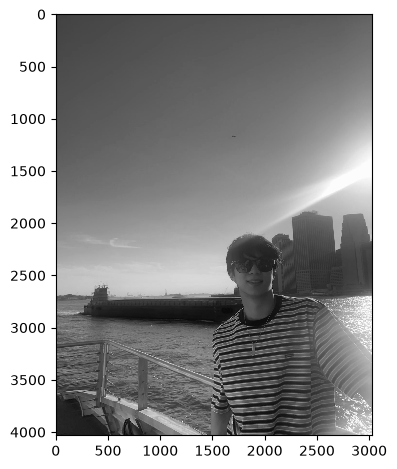

In [2]:
import numpy as np
import skimage as sk
import skimage.io as skio

imname = 'images/me.jpg'

im = skio.imread(imname)
im = sk.img_as_float(im)

im = sk.color.rgb2gray(im)
im = sk.transform.rescale(im, 1/3, anti_aliasing=True)

skio.imshow(im)
skio.show()

In [3]:
def convolution_4d(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape
    kernel = kernel[::-1,::-1]

    if padding == "same":
        # (m - h + 1) + 2 * pad = m -> 2 * pad = h - 1 -> odd kernel, pad = h // 2
        pad_h = h // 2
        pad_w = w // 2
    elif padding == "full":
        pad_h = h - 1
        pad_w = w - 1

    img_pad = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)))

    h_out = img_pad.shape[0] - h + 1
    w_out = img_pad.shape[1] - w + 1

    img_out = np.zeros(shape=(h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            val = 0
            for k in range(h):
                for l in range(w):
                    val += kernel[k][l] * img_pad[i+k][j+l]
            img_out[i][j] = val

    return img_out


In [6]:
def convolution_2d(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape
    kernel = kernel[::-1,::-1]

    if padding == "same":
        # (m - h + 1) + 2 * pad = m -> 2 * pad = h - 1 -> odd kernel, pad = h // 2
        pad_h = h // 2
        pad_w = w // 2
    elif padding == "full":
        pad_h = h - 1
        pad_w = w - 1

    img_pad = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)))

    h_out = img_pad.shape[0] - h + 1
    w_out = img_pad.shape[1] - w + 1

    img_out = np.zeros(shape=(h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            img_out[i][j] = np.sum(kernel * img_pad[i:i+h,j:j+w])

    return img_out


/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/2865058824.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(np.clip(imbox + 0.5, 0, 1))
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/2865058824.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


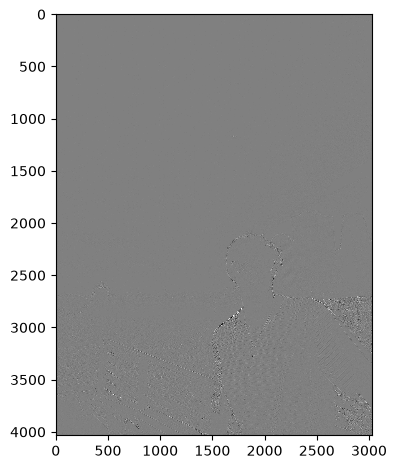

In [9]:
box = np.ones((9, 9)) / 81

imbox = convolution_4d(im, box, "full")

skio.imshow(np.clip(imbox + 0.5, 0, 1))
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/4287399370.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(np.clip(imbox + 0.5, 0, 1))
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/4287399370.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


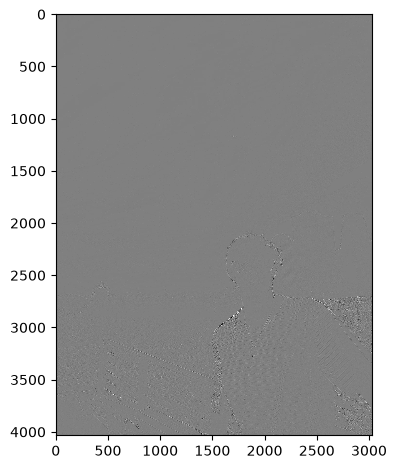

In [8]:
box = np.ones((9, 9)) / 81

imbox = convolution_2d(im, box, "full")

skio.imshow(np.clip(imbox + 0.5, 0, 1))
skio.show()

In [10]:
from scipy.signal import convolve2d

def convolution(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape

    if padding == "same":
        mode = "same"
    elif padding == "full":
        mode = "full"
    else:
        mode = "valid"

    img_out = convolve2d(img, kernel, mode=mode)

    return img_out

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/2982163235.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(np.clip(imbox + 0.5, 0, 1))
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_76544/2982163235.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


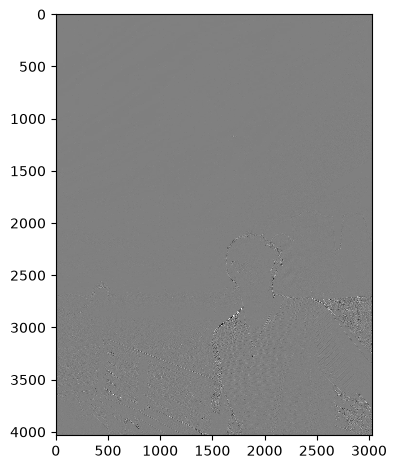

In [11]:
box = np.ones((9, 9)) / 81

imbox = convolution(im, box, "full")

skio.imshow(np.clip(imbox + 0.5, 0, 1))
skio.show()

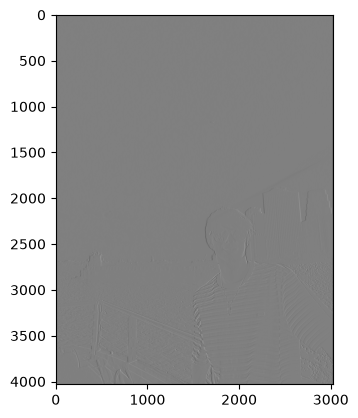

In [18]:
import matplotlib.pyplot as plt

Dx = np.array([[1, 0, -1]])
Dy = np.array([[1], [0], [-1]])

imx = convolution(im, Dx, "same")

plt.imshow(np.clip(imx + 0.5, 0, 1), cmap="gray")
plt.show()

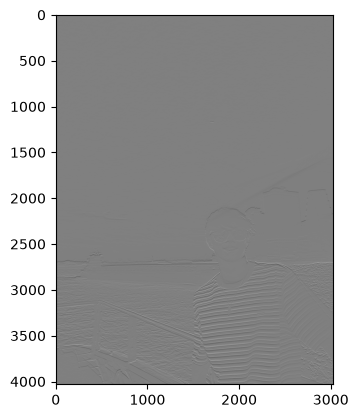

In [19]:
imy = convolution(im, Dy, "same")

plt.imshow(np.clip(imy + 0.5, 0, 1), cmap="gray")
plt.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_40923/266416582.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(imx_prime)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_40923/266416582.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


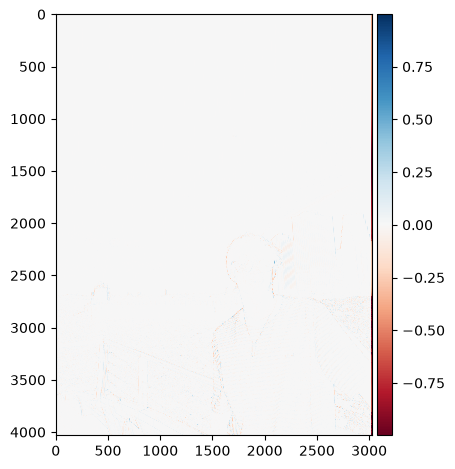

In [21]:
from scipy import signal

imx_prime = signal.convolve2d(im, Dx, mode='same', boundary='fill', fillvalue=0)

skio.imshow(imx_prime)
skio.show()

In [22]:
np.array_equal(imx, imx_prime)

True